# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [ ]:
import os
if not os.path.exists('zh03-causal-discovery-robust-predictions'):
    !git clone https://github.com/WinterSchool2026/zh03-causal-discovery-robust-predictions.git
import sys
sys.path.insert(0, 'zh03-causal-discovery-robust-predictions')

In [1]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


# Causal feature selection
from src.causal_feature_selection import (
    hiton_mb, iamb, mmpc, mb_ges, resit_mb, hiton_pc
)
from invariant_causal_prediction import icp

# data generation
from src.generate_scm import *

# Reproducibility
np.random.seed(2)

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


---
## Section 5 — Invariant Causal Predictors (ICP)

### 5.1 Motivation

In the previous section, we argued that the parents of Y are robust to intervention shifts. But in practice, we don't have access to the causal graph. We also don't always have a clear MB estimate.

**Invariant Causal Prediction** (Peters, Bühlmann, Meinshausen, 2016) takes a different angle: instead of first recovering the graph and then selecting parents, it directly asks:

*"Which set of features S produces a linear regression of Y on X_S whose coefficients and residual distribution are stable across different experimental conditions (environments)?"*

The central claim: the causal parents of Y are exactly the unique minimal set S* for which the conditional distribution P(Y | X_{S*}) is the same across all environments induced by interventions on non-Y variables.

### 5.2 The algorithm

**Input**: data from multiple environments E_1, E_2, ..., E_K (e.g., different experimental conditions, time periods, hospital sites).

**For each candidate feature set S**:
1. Fit a linear model Y ~ X_S in each environment
2. Test whether the coefficients and residual variance are equal across environments (using F-tests or likelihood ratio tests)
3. If the model is invariant across environments, S is a *plausible* causal set

**Output**: The intersection of all invariant sets — this is the ICP estimate of the causal parents.

### 5.3 Multiple environments are required

ICP needs data from more than one environment to test invariance. Without this, any set of features is trivially "invariant" (no comparison is possible). The environments should differ in terms of which variables were intervened on.

In the experiment below, we simulate two environments by intervening on different non-Y variables.


In [ ]:
# Build the SCM (same structure as Section 4 for comparability)
d = 10
scm = SCMGenerator(d=d)
A = generate_dag(num_vars=d+1, n_parents=2, n_children=2, n_spouses=1, sparsity=0.15)
scm.fit_from_adjacency(A, Y_idx=d, noise_type='uniform', is_linear=True)

col_names = np.hstack((np.array([f'X{i}' for i in range(scm.n_nodes-1)]), np.array(['Y'])))
plot_graphs_from_adj([scm.A], [d], [col_names], ['True DAG'])

print("Parents of Y: ", sorted(scm.parents_idx))
print("Children of Y:", sorted(scm.children_idx))
print("Spouses of Y: ", sorted(scm.spouses_idx))
print("Others:       ", sorted(scm.others_idx))


ValueError: Adjacency matrix contains cycles.

In [ ]:
# Generate multi-environment data
# -----------------------------------------------------------
# We intervene on all non-parent nodes (children, spouses, others)
# Each gets its own environment with a random constant intervention.
# The observational data is environment 0.
# -----------------------------------------------------------

N = 10000
intervened = np.hstack([scm.children_idx, scm.others_idx, scm.spouses_idx])
n_per_env = N // len(intervened)

# Observational environment
data_obs = scm.sample(n_samples=n_per_env)
data_full_list = [data_obs.values]
env_labels = [np.zeros(data_obs.shape[0], dtype=int)]

for k, node_idx in enumerate(intervened):
    intervention_val = np.random.uniform(5, 10)
    scm_int = scm.intervention(indices=[node_idx], values=[intervention_val])
    data_int = scm_int.sample(n_samples=n_per_env)
    data_full_list.append(data_int.values)
    env_labels.append(np.full(n_per_env, k + 1, dtype=int))

data_all = np.vstack(data_full_list)
env_idx  = np.hstack(env_labels)

print(f"Total samples: {data_all.shape[0]}")
print(f"Number of environments: {len(np.unique(env_idx))}  (0 = observational, rest = interventional)")
print(f"Variables shape: {data_all[:, :-1].shape}  ->  target shape: {data_all[:, -1].shape}")


Total samples: 11250
Number of environments: 9  (0 = observational, rest = interventional)
Variables shape: (11250, 10)  ->  target shape: (11250,)


### 5.3 Running ICP

The `icp` function tests all feature subsets for invariance of the linear model across environments. It returns, among other things, `maximin_coefficients` — coefficients that are non-zero only for features that are robustly predictive across all environments.


In [ ]:
# Run ICP
# X = all features (columns 0..d-1), y = target (column d)
res = icp(data_all[:, :-1], data_all[:, -1], env_idx, alpha=0.05)

# Extract ICP-selected predictor indices
icp_idx = np.where(
    (res['maximin_coefficients'] != 0) &
    (~np.isnan(res['maximin_coefficients']))
)[0]

print("ICP-selected predictor indices:", icp_idx)
print("ICP-selected predictor names:  ", [f'X{i}' for i in icp_idx])
print("\nTrue parent indices:           ", sorted(scm.parents_idx))
print("True parent names:             ", [f'X{i}' for i in sorted(scm.parents_idx)])


ICP-selected predictor indices: [0 3 4 5 6 7 9]
ICP-selected predictor names:   ['X0', 'X3', 'X4', 'X5', 'X6', 'X7', 'X9']

True parent indices:            [np.int64(5), np.int64(7)]
True parent names:              ['X5', 'X7']


### 5.4 Robustness under intervention: ICP vs full predictor

Now we compare two predictors on out-of-distribution data:
- **All features**: trained on all X columns
- **ICP features**: trained only on the ICP-selected columns

We sweep intervention strength across the four node groups (parents, children, spouses, others) and track R².


In [ ]:
# Fit predictors on observational data only
data_obs_df = pd.DataFrame(data_obs, columns=col_names)
X_obs = data_obs_df.drop(columns='Y').values
y_obs = data_obs_df['Y'].values

lr_full = LinearRegression().fit(X_obs, y_obs)

icp_col_names = [f'X{i}' for i in icp_idx]
X_icp_obs = data_obs_df[icp_col_names].values if len(icp_col_names) > 0 else X_obs
lr_icp = LinearRegression().fit(X_icp_obs, y_obs)

print(f"Observational R² — full: {lr_full.score(X_obs, y_obs):.4f}")
print(f"Observational R² — ICP:  {lr_icp.score(X_icp_obs, y_obs):.4f}")


Observational R² — full: 0.9819
Observational R² — ICP:  0.9423


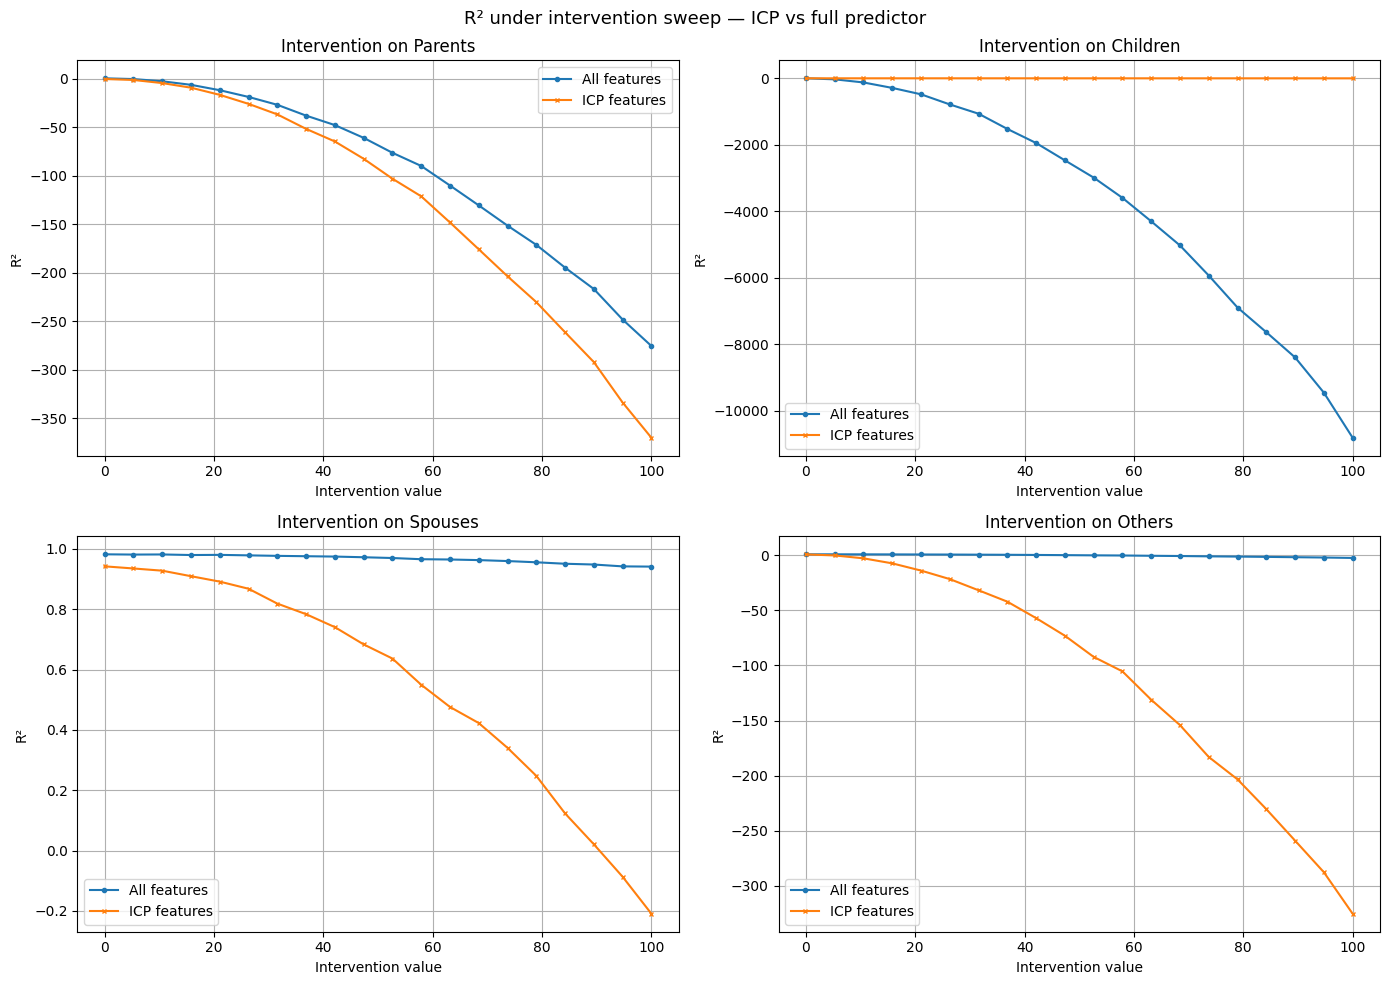

In [ ]:
# Sweep interventions and plot R² curves
intervention_values = np.linspace(0, 100, 20)

intervention_groups = {
    'Parents':  scm.parents_idx,
    'Children': scm.children_idx,
    'Spouses':  scm.spouses_idx,
    'Others':   scm.others_idx
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (group_name, indices) in enumerate(intervention_groups.items()):
    r2_full_list, r2_icp_list = [], []
    indices_list = list(indices)

    for val in intervention_values:
        scm_int = scm.intervention(indices=indices_list, values=[val]*len(indices_list))
        data_int = scm_int.sample(n_samples=5000)
        data_int_df = pd.DataFrame(data_int, columns=col_names)

        X_int_full = data_int_df.drop(columns='Y').values
        X_int_icp  = data_int_df[icp_col_names].values if len(icp_col_names) > 0 else X_int_full
        y_int      = data_int_df['Y'].values

        r2_full_list.append(lr_full.score(X_int_full, y_int))
        r2_icp_list.append(lr_icp.score(X_int_icp, y_int))

    axes[i].plot(intervention_values, r2_full_list, label='All features', marker='o', markersize=3)
    axes[i].plot(intervention_values, r2_icp_list,  label='ICP features', marker='x', markersize=3)
    axes[i].set_title(f'Intervention on {group_name}')
    axes[i].set_xlabel('Intervention value')
    axes[i].set_ylabel('R²')
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle('R² under intervention sweep — ICP vs full predictor', fontsize=13)
plt.tight_layout()
plt.show()


### 5.5 Full comparison: all selectors side by side

Let's now bring together all approaches — full predictor, MB-GES, HITON-PC, and ICP — on the same plots.


In [ ]:
# First, re-run CFS algorithms on observational data
mb_ges_res   = mb_ges(data_obs_df, 'Y')
mb_hiton_pc  = hiton_pc(data_obs_df, 'Y', alpha=0.05, ci_method='partial')

lr_ges  = LinearRegression().fit(data_obs_df[mb_ges_res].values, y_obs)
lr_pc   = LinearRegression().fit(data_obs_df[mb_hiton_pc].values, y_obs) if mb_hiton_pc else lr_full

print(f"MB-GES features:   {sorted(mb_ges_res)}")
print(f"HITON-PC features: {sorted(mb_hiton_pc)}")
print(f"ICP features:      {sorted(icp_col_names)}")
print(f"True parents:      {[f'X{i}' for i in sorted(scm.parents_idx)]}")


MB-GES features:   ['X1', 'X2', 'X3', 'X5', 'X7']
HITON-PC features: ['X2', 'X5', 'X7']
ICP features:      ['X0', 'X3', 'X4', 'X5', 'X6', 'X7', 'X9']
True parents:      ['X5', 'X7']


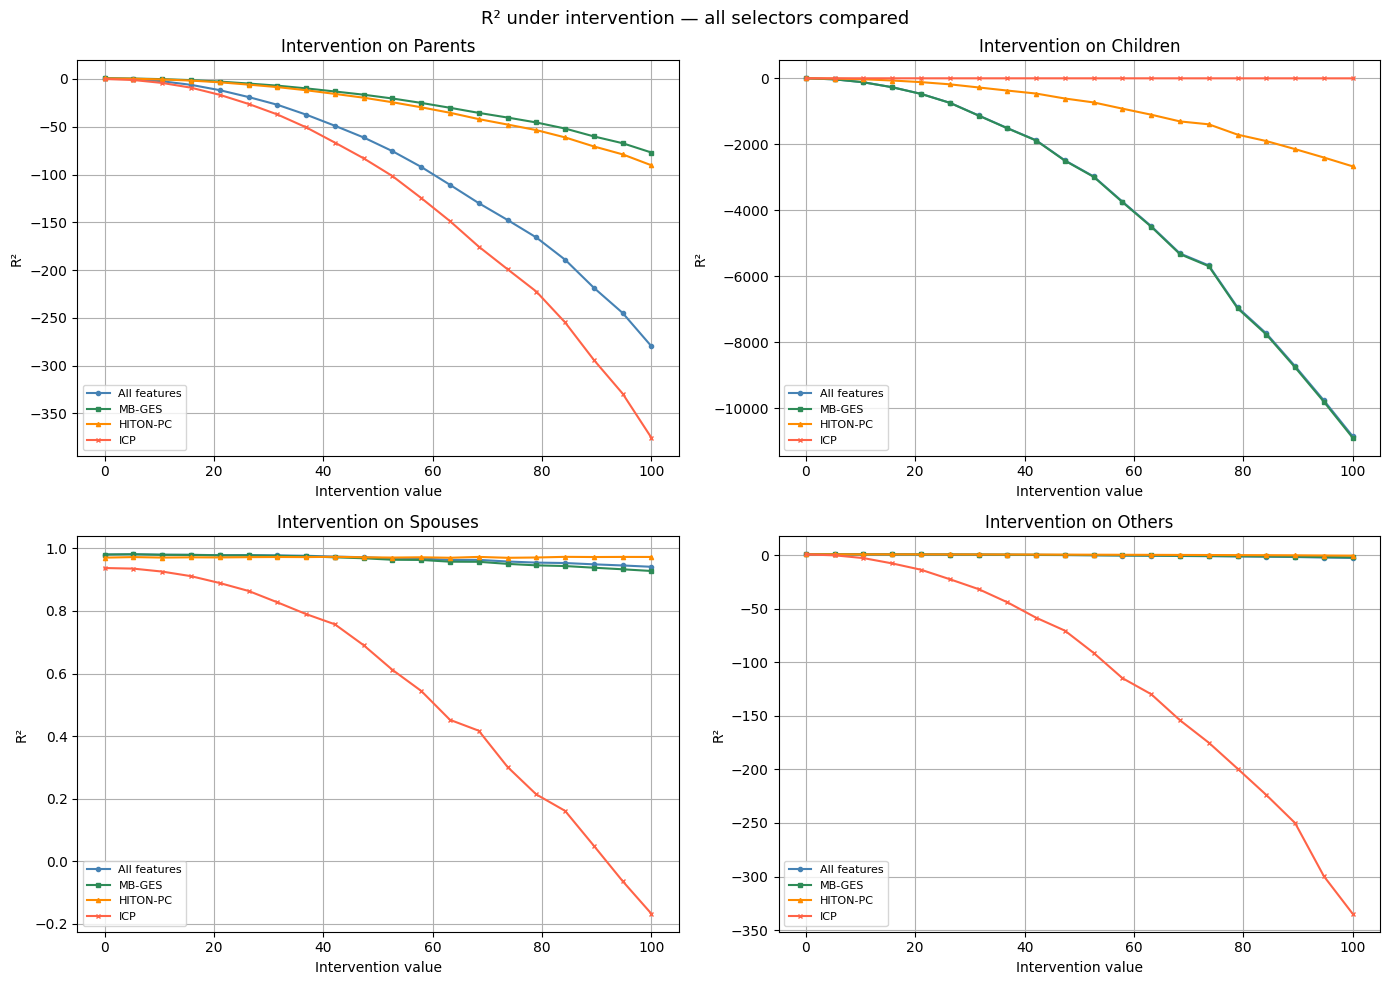

In [ ]:
# Full 4-panel comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

selectors = {
    'All features': (lr_full,  lambda df: df.drop(columns='Y').values),
    'MB-GES':       (lr_ges,   lambda df: df[mb_ges_res].values),
    'HITON-PC':     (lr_pc,    lambda df: df[mb_hiton_pc].values if mb_hiton_pc else df.drop(columns='Y').values),
    'ICP':          (lr_icp,   lambda df: df[icp_col_names].values if icp_col_names else df.drop(columns='Y').values),
}
colors = ['steelblue', 'seagreen', 'darkorange', 'tomato']
markers = ['o', 's', '^', 'x']

for i, (group_name, indices) in enumerate(intervention_groups.items()):
    indices_list = list(indices)
    r2_by_selector = {name: [] for name in selectors}

    for val in intervention_values:
        scm_int = scm.intervention(indices=indices_list, values=[val]*len(indices_list))
        data_int = scm_int.sample(n_samples=3000)
        data_int_df = pd.DataFrame(data_int, columns=col_names)
        y_int = data_int_df['Y'].values

        for name, (model, feat_fn) in selectors.items():
            X_int = feat_fn(data_int_df)
            r2_by_selector[name].append(model.score(X_int, y_int))

    for (name, r2s), color, marker in zip(r2_by_selector.items(), colors, markers):
        axes[i].plot(intervention_values, r2s, label=name, color=color,
                     marker=marker, markersize=3, linewidth=1.5)

    axes[i].set_title(f'Intervention on {group_name}')
    axes[i].set_xlabel('Intervention value')
    axes[i].set_ylabel('R²')
    axes[i].grid(True)
    axes[i].legend(fontsize=8)

plt.suptitle('R² under intervention — all selectors compared', fontsize=13)
plt.tight_layout()
plt.show()


### Questions — ICP

**Q19.** ICP needs data from multiple environments. Look at how the environments were generated above. Why did we intervene only on non-parent nodes? What would happen to ICP's guarantee if we also included an environment where a parent of Y was intervened on?

**Q20.** ICP's output is the *intersection* of all invariant sets. This is a conservative operation. What does it guarantee statistically, and what does it sacrifice?

**Q21.** In the plots above, the ICP R² curve should be flat (or nearly so) when intervening on non-parent nodes, but can drop when intervening on parents. Explain both behaviors.

**Q22.** ICP has complexity O(2^p) — it tests all subsets. For p=10 that is 1024 tests; for p=50 it is 10^15. Describe two practical strategies to scale ICP to higher dimensions, and state what each sacrifices.

**Q23.** Compare the observational R² of the ICP predictor vs. the full predictor. There is usually a gap. Is this a bug or a feature? When would you accept this tradeoff in practice?


**Answers:**

**A19.** ICP's core claim: the conditional distribution P(Y | X_{parents}) is invariant *to interventions on other variables*. If we include an environment where a parent is intervened on, the conditional Y | X_{parent} can change (the parent's value is forced, but Y's noise and mechanism are the same — yet the distribution of Y given the now-constant parent shifts in terms of marginal distribution). More critically: if a parent is intervened on, other feature sets may appear spuriously "invariant" in that environment, polluting the invariance test. ICP's guarantee breaks down. In practice, you'd need to know which environments correspond to which types of interventions, or use a more robust version (like hiddenICP).

**A20.** The intersection guarantees that any variable in the ICP estimate is *truly* in every invariant set found — limiting false positives (non-parents included). Formally, ICP controls the false discovery rate at level α: with probability ≥ 1-α, all returned variables are true parents. The sacrifice is power: true parents may be missed (false negatives), especially when there are few environments or the invariance signal is weak. The method errs on the side of caution, returning fewer variables with higher confidence.

**A21.** Flat ICP curve under non-parent interventions: Y's structural equation Y = f(parents) + ε is untouched. The ICP features (true or estimated parents) still have their natural relationship with Y intact. The model extrapolates to new parent values in a structurally correct way, so R² stays stable. Drop under parent interventions: same R² collapse discussed in Q17 — when all units share the same parent value, variance in Y is purely noise, and R² ≈ 0 by definition regardless of predictor quality. This is an artifact of the R² metric, not a failure of the predictor.

**A22.** Strategy 1 — **Lasso pre-screening**: run a penalized regression (Lasso or Ridge) across environments to get a small candidate set, then test only subsets of that. Sacrifice: if the true parent is not in the Lasso solution (due to collinearity or regularization), it will be missed — the pre-screening step can introduce false negatives. Strategy 2 — **Greedy/forward ICP**: instead of all subsets, start from the empty set and greedily add the feature that most increases invariance score. Stop when no addition improves it. Sacrifice: the greedy search may miss the global invariant set, especially when individual features are only invariant *in combination* (interactions). Both strategies trade completeness for tractability.

**A23.** This is a feature. The ICP predictor deliberately excludes features that are predictive in the training distribution but not causally connected to Y. Those features carry signal only because of spurious correlations in the training data. In any deployment environment that differs from training, that signal may vanish. The observational R² gap reflects the cost of robustness — you give up some in-sample performance in exchange for stability. You would accept this tradeoff whenever you expect distribution shifts at deployment: clinical settings with protocol variations, recommender systems subject to feedback loops, industrial sensors under changing operating conditions.


### Exercise 5 — What if environments are created by intervening on a parent?

Re-generate the multi-environment data, but this time include one environment where a *parent* of Y is the intervention target (alongside the non-parent environments). Rerun ICP and compare the estimated parents to the true ones. Does the output change? Does ICP's guarantee still hold?


In [ ]:
# Your code here
# Hint: pick one parent index from scm.parents_idx
# Add it to the list of intervened nodes when building data_full_list
# Then re-run: res = icp(data_all[:, :-1], data_all[:, -1], env_idx, alpha=0.05)
# Compare icp_idx to scm.parents_idx


---
## Wrapping up

This tutorial covered four increasingly powerful tools for using causality in prediction:

1. **Pairwise RESIT**: exploit noise asymmetry to determine causal direction between two variables. Works for non-Gaussian or nonlinear ANMs.

2. **Multivariate causal discovery** (PC, GES, FCI): recover the causal graph from observational data. Different algorithms make different assumptions (causal sufficiency, linearity, faithfulness). None can orient all edges from observational data alone.

3. **Markov Blanket algorithms** (HITON-MB, IAMB, MB-GES, RESIT-MB): identify the minimal sufficient feature set for predicting Y. Avoids full graph recovery. Useful for prediction and understanding local structure.

4. **Causal Feature Selection for robustness**: the parents of Y are invariant across intervention shifts. Using them as features gives predictors that degrade less dramatically when the test distribution shifts.

5. **ICP**: a multi-environment method that identifies causal parents directly from invariance across conditions, without requiring full graph recovery. Statistically principled but requires multiple environments and does not scale naively to high dimensions.

The broader lesson: **correlation-based feature selection is not robust under distribution shift. Causal structure, whether recovered via discovery or exploited via invariance, can provide a principled foundation for stable, generalizable prediction.**
